In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# load the block model
df = pd.read_csv('block_model.csv')

# Set a baseline carbon price ($/tonne of CO2) for this initial computation
carbon_price = 50.0  

# 2. Calculate absolute GHG emissions per block (in Metric Tonnes)
# Formula: (kg CO2 / tonne) * (kilotonnes) = Metric Tonnes of CO2
df['total_ghg_tonnes'] = df['ghg_kg_co2_per_t'] * df['tonnage_kt']

# 3. Compute carbon_cost = ghg * price
df['carbon_cost'] = df['total_ghg_tonnes'] * carbon_price

# Preview the results to verify the math
print("--- Block Model Data with Carbon Cost ---")
print(df[['block_id', 'tonnage_kt', 'ghg_kg_co2_per_t', 'total_ghg_tonnes', 'carbon_cost']].sample(10))

--- Block Model Data with Carbon Cost ---
    block_id  tonnage_kt  ghg_kg_co2_per_t  total_ghg_tonnes  carbon_cost
411    B0411       566.6             27.90         15808.140    790407.00
175    B0175       417.2             29.77         12420.044    621002.20
489    B0489       444.0             29.01         12880.440    644022.00
28     B0028       368.8             21.34          7870.192    393509.60
78     B0078       533.8             27.94         14914.372    745718.60
8      B0008       544.2             22.52         12255.384    612769.20
320    B0320       423.2             33.34         14109.488    705474.40
418    B0418       423.2             22.44          9496.608    474830.40
123    B0123       338.1             22.12          7478.772    373938.60
446    B0446       395.1             23.41          9249.291    462464.55


In [3]:
# calculate the absolute operating costs for each block (tonnage_kt * 1000 converts to tonnes)
df['total_mining_cost'] = df['mining_cost_t'] * (df['tonnage_kt'] * 1000)
df['total_processing_cost'] = df['processing_cost_t'] * (df['tonnage_kt'] * 1000)

# sum everything up to get the mine-wide totals!
mine_mining_cost = df['total_mining_cost'].sum()
mine_processing_cost = df['total_processing_cost'].sum()

# 1. This is the total GHG tonnage for the entire mine:
mine_ghg_tons = df['total_ghg_tonnes'].sum()

# 2. This is the base cost (Mining + Processing) BEFORE any carbon taxes:
total_base_op_cost = mine_mining_cost + mine_processing_cost

print(f"\nMine-Wide Totals for Monte Carlo:")
print(f"Total Base Op Cost: ${total_base_op_cost:,.2f}")
print(f"Total GHG Emissions: {mine_ghg_tons:,.2f} Metric Tonnes")


Mine-Wide Totals for Monte Carlo:
Total Base Op Cost: $4,103,075,488.00
Total GHG Emissions: 6,893,166.98 Metric Tonnes


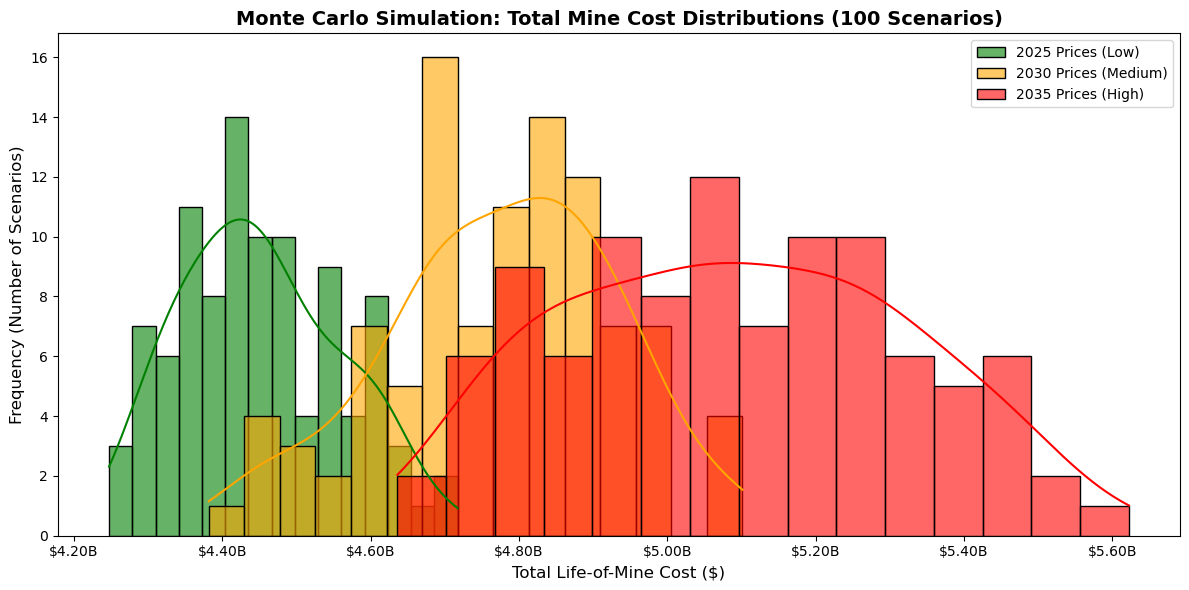

In [4]:
import seaborn as sns
# The CSV contains 100 rows (scenarios) of potential future market conditions
df_scenarios = pd.read_csv('carbon_scenarios.csv')

# We calculate 3 separate lists of 100 costs based on the prices in 2025, 2030, and 2035.
# total_cost = base_cost + (total_emissions * scenario_carbon_price)
total_cost_2025 = total_base_op_cost + (mine_ghg_tons * df_scenarios['carbon_price_2025'])
total_cost_2030 = total_base_op_cost + (mine_ghg_tons * df_scenarios['carbon_price_2030'])
total_cost_2035 = total_base_op_cost + (mine_ghg_tons * df_scenarios['carbon_price_2035'])

# plot cost distributions under low/medium/high carbon prices
plt.figure(figsize=(12, 6))
# Plotting the three distinct time horizons (Low = 2025, Medium = 2030, High = 2035)
sns.histplot(total_cost_2025, color='green', label='2025 Prices (Low)', kde=True, bins=15, alpha=0.6)
sns.histplot(total_cost_2030, color='orange', label='2030 Prices (Medium)', kde=True, bins=15, alpha=0.6)
sns.histplot(total_cost_2035, color='red', label='2035 Prices (High)', kde=True, bins=15, alpha=0.6)

plt.title('Monte Carlo Simulation: Total Mine Cost Distributions (100 Scenarios)', fontsize=14, fontweight='bold')
plt.xlabel('Total Life-of-Mine Cost ($)', fontsize=12)
plt.ylabel('Frequency (Number of Scenarios)', fontsize=12)

# Helper function to format the X-axis cleanly in Billions ($B) or Millions ($M)
def format_currency(x, pos):
    if x >= 1e9:
        return f'${x / 1e9:.2f}B'
    return f'${x / 1e6:.0f}M'

plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_currency))

plt.legend()
plt.tight_layout()

# Display the plot
plt.show()


In [5]:
print("--- Expected Average Mine Costs ---")
print(f"If starting in 2025: ${total_cost_2025.mean() / 1e9:.2f} Billion")
print(f"If starting in 2030: ${total_cost_2030.mean() / 1e9:.2f} Billion")
print(f"If starting in 2035: ${total_cost_2035.mean() / 1e9:.2f} Billion")

--- Expected Average Mine Costs ---
If starting in 2025: $4.45 Billion
If starting in 2030: $4.78 Billion
If starting in 2035: $5.09 Billion


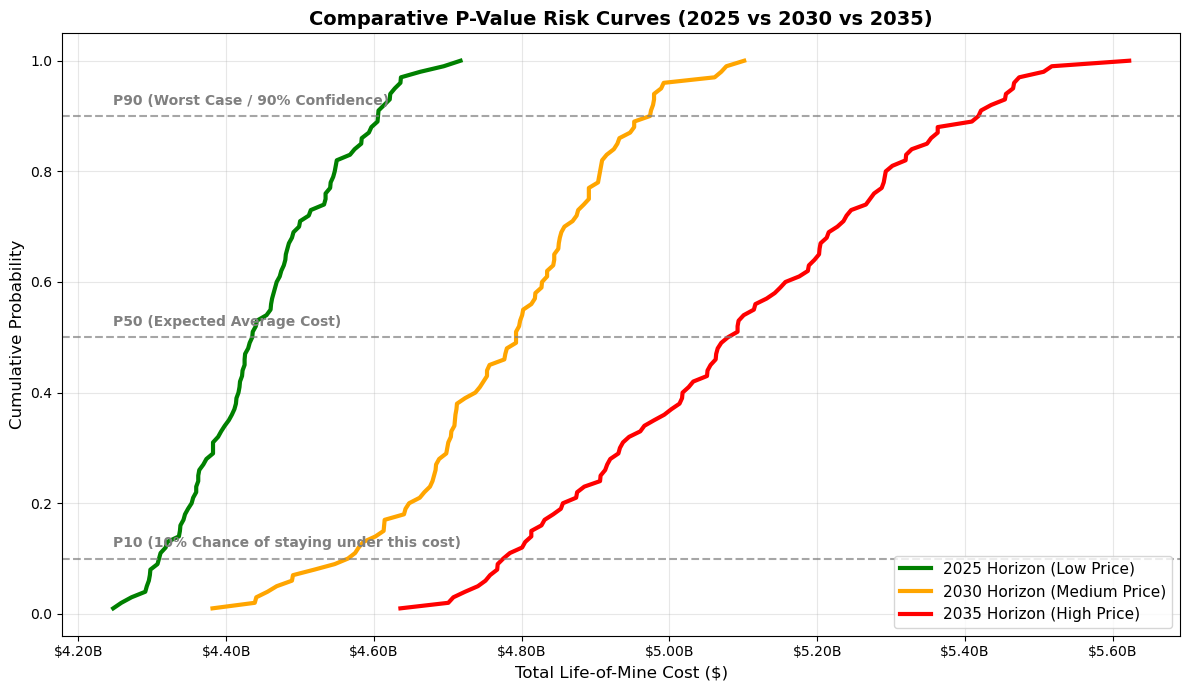

In [7]:
import numpy as np

plt.figure(figsize=(12, 7))

# Calculate the Y-axis probabilities (0.0 to 1.0)
# Since all three scenarios have 100 data points, they share the same Y-axis scale
y_vals = np.arange(1, len(total_cost_2025) + 1) / len(total_cost_2025)

# Sort the costs for all three horizons from lowest to highest
sorted_2025 = np.sort(total_cost_2025)
sorted_2030 = np.sort(total_cost_2030)
sorted_2035 = np.sort(total_cost_2035)

# Plot the three S-Curves
plt.plot(sorted_2025, y_vals, color='green', linewidth=3, label='2025 Horizon (Low Price)')
plt.plot(sorted_2030, y_vals, color='orange', linewidth=3, label='2030 Horizon (Medium Price)')
plt.plot(sorted_2035, y_vals, color='red', linewidth=3, label='2035 Horizon (High Price)')

# Add clean, horizontal reference lines for P10, P50, and P90
plt.axhline(0.10, color='gray', linestyle='--', alpha=0.7)
plt.text(sorted_2025[0], 0.12, 'P10 (10% Chance of staying under this cost)', color='gray', fontweight='bold')

plt.axhline(0.50, color='gray', linestyle='--', alpha=0.7)
plt.text(sorted_2025[0], 0.52, 'P50 (Expected Average Cost)', color='gray', fontweight='bold')

plt.axhline(0.90, color='gray', linestyle='--', alpha=0.7)
plt.text(sorted_2025[0], 0.92, 'P90 (Worst Case / 90% Confidence)', color='gray', fontweight='bold')

# Chart Formatting
plt.title('Comparative P-Value Risk Curves (2025 vs 2030 vs 2035)', fontsize=14, fontweight='bold')
plt.xlabel('Total Life-of-Mine Cost ($)', fontsize=12)
plt.ylabel('Cumulative Probability', fontsize=12)

# Apply the currency formatter we defined earlier
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(format_currency))

# Place the legend in the bottom right so it doesn't cover the top of the S-curves
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()

# Display the plot
plt.show()

If you lock in a budget today assuming 2025 carbon prices, but the market shifts to the 2035 reality, your P90 worst-case scenario blows past $5 Billion.
That's we need advanced optimization techniques for efficient long term mine planning.